Импорт библиотек

In [47]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

Загрузка датасета

In [48]:
file_path = 'Wrongful Convictions in the United States.csv'

df = pd.read_csv(file_path)

# Задание 1

Как выглядят колонки

In [49]:
df.head()

,Unnamed: 0,Date of the Crime,Defendants,Type of the Crime,Location of the Crime,Punishment for a crime,Legally Exonerated,Legally Exonerated Encoded
0,0,1805,Dominic Daley and James Halligan,murder,Massachusetts,death,yes,1
1,1,1843,John Gordon,murder,Rhode Island,death,yes,1
2,2,1855,Chief Leschi,murder,Washington,death,no,0
3,3,1863,Chipita Rodriguez,murder,Texas,death,yes,1
4,4,1872,William Jackson Marion,murder,Nebraska,death,yes,1


Информация о типах данных

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Unnamed: 0                  178 non-null    int64
 1   Date of the Crime           178 non-null    int64
 2   Defendants                  178 non-null    str  
 3   Type of the Crime           178 non-null    str  
 4   Location of the Crime       178 non-null    str  
 5   Punishment for a crime      169 non-null    str  
 6   Legally Exonerated          178 non-null    str  
 7   Legally Exonerated Encoded  178 non-null    int64
dtypes: int64(3), str(5)
memory usage: 11.3 KB


Сколько пропусков

In [51]:
df.isnull().sum()

Unnamed: 0                    0
Date of the Crime             0
Defendants                    0
Type of the Crime             0
Location of the Crime         0
Punishment for a crime        9
Legally Exonerated            0
Legally Exonerated Encoded    0
dtype: int64

Есть ли дубликаты

In [52]:
df.duplicated().sum()

np.int64(0)

# Удаляю колонку с номером строки, колонку с именем и две дублирующие друг друга колонки(yes, no and 0,1)

In [53]:
df = df.drop(columns=['Unnamed: 0'])
df = df.drop(columns=['Legally Exonerated'])
df = df.drop(columns=['Defendants'])

Корреляции

/var/folders/cc/m264jryj4vqfwvvrwjj56tbh0000gn/T/ipykernel_27418/1356937117.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include=['object']).columns:


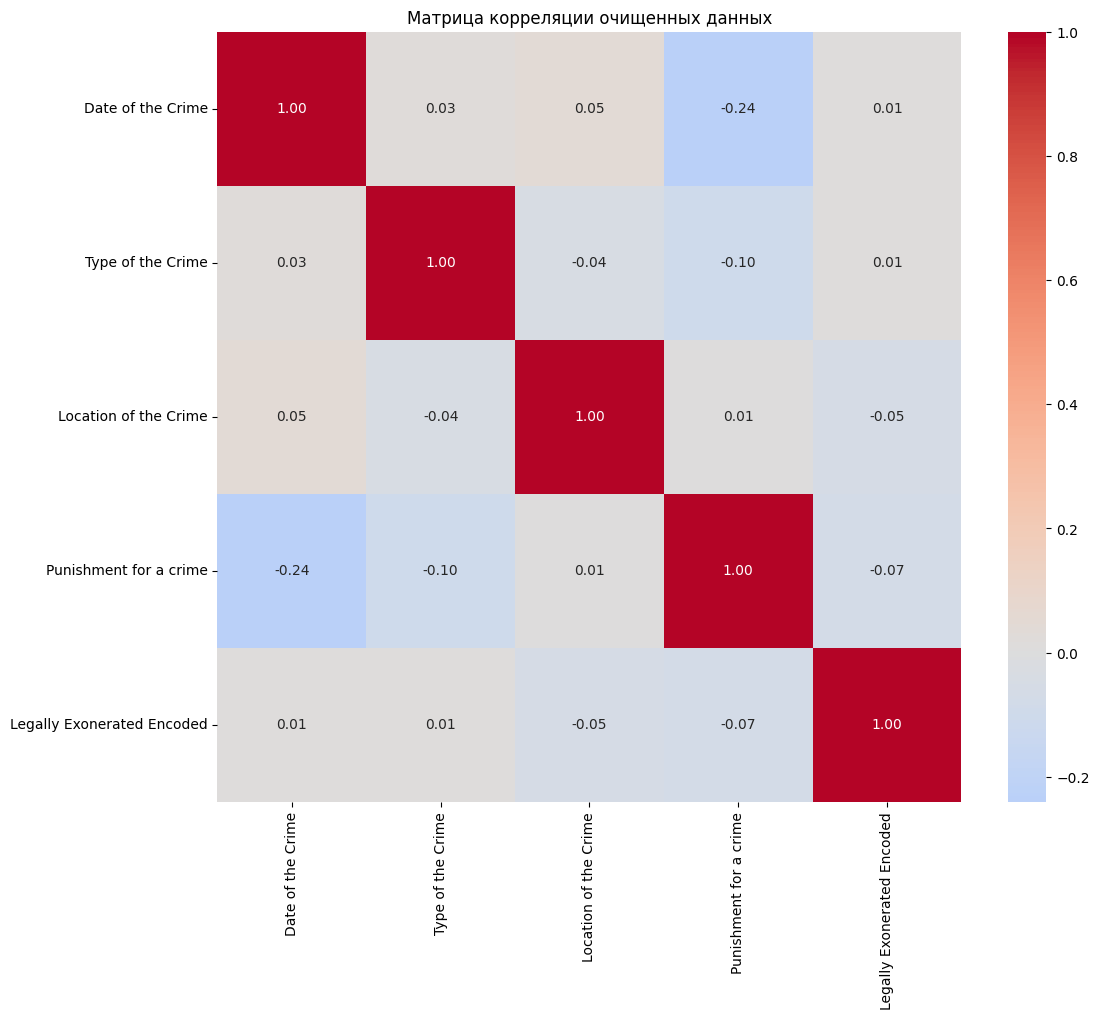

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. Подготовка данных для корреляции
df_corr = df.copy()

# Кодируем категориальные признаки в числа
le = LabelEncoder()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# 2. Расчет матрицы корреляции
corr_matrix = df_corr.corr()

# 3. Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Матрица корреляции очищенных данных")
plt.show()

Извлекаю только год из даты

In [55]:
df['Date of the Crime'] = pd.to_datetime(df['Date of the Crime'], errors='coerce').dt.year

Кодирую признаки

In [56]:
le = LabelEncoder()
categorical_cols = ['Type of the Crime', 'Location of the Crime', 'Punishment for a crime']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

????

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Задание 2

Метод локтя, на 4 изгиб

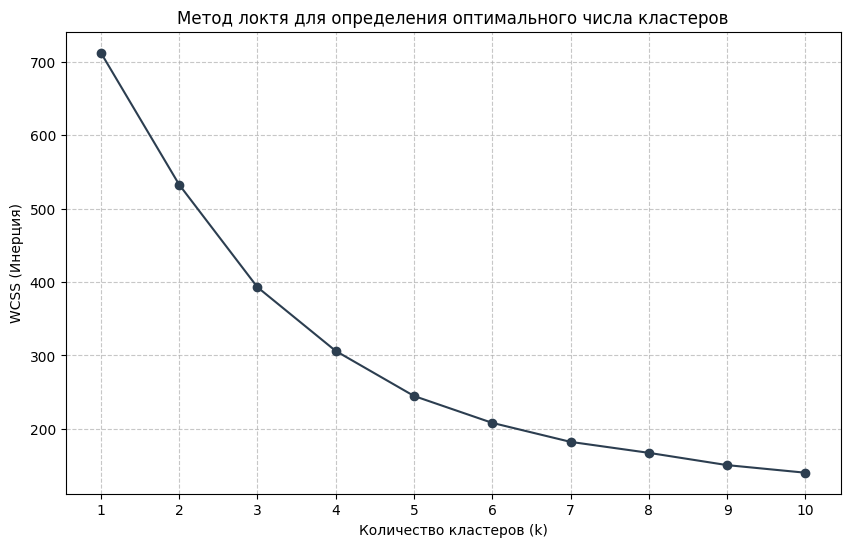

In [58]:
wcss = []

# Проверяем количество кластеров от 1 до 10
for i in range(1, 11):
    # Используем k-means++ для более стабильных результатов
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Визуализация графика локтя
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='#2c3e50')
plt.title('Метод локтя для определения оптимального числа кластеров')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)

# Добавим аннотацию для наглядности (если на графике будет явный изгиб)
plt.show()

# Задание 3

Кластерезуем

In [60]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby('Cluster').mean()

cluster_profile['Count'] = df['Cluster'].value_counts()

print(cluster_profile)

         Date of the Crime  Type of the Crime  Location of the Crime  \
Cluster                                                                
0                   1970.0          24.000000              16.526316   
1                   1970.0          17.109091              29.000000   
2                   1970.0          17.266667               9.700000   
3                   1970.0          18.560000              20.000000   

         Punishment for a crime  Legally Exonerated Encoded  Count  
Cluster                                                             
0                     11.684211                         1.0     38  
1                     34.236364                         1.0     55  
2                     35.266667                         1.0     60  
3                     31.480000                         0.0     25  


# Задание 4

Отчёт по кластерам

In [62]:
df_final_report = df.copy()

original_df = pd.read_csv('Wrongful Convictions in the United States.csv')

final_table = original_df.loc[df.index].copy()
final_table['Cluster'] = df['Cluster']

for cluster_num in range(4):
    print(f"\nКЛАСТЕР №{cluster_num}:")
    # Показываем 5 случайных примеров из этого кластера
    display_cols = ['Date of the Crime', 'Type of the Crime', 'Location of the Crime', 'Punishment for a crime', 'Legally Exonerated']
    print(final_table[final_table['Cluster'] == cluster_num][display_cols].head(5))

print("\n--- Типичные характеристики кластеров (Мода) ---")
cluster_summary = final_table.groupby('Cluster')[display_cols].agg(lambda x: x.mode()[0])
print(cluster_summary)

--- Примеры данных по кластерам ---

КЛАСТЕР №0:
    Date of the Crime Type of the Crime Location of the Crime  \
5                1886  haymarket affair              Illinois   
31               1975            murder              New York   
40               1977              rape              Illinois   
42               1978              rape              Illinois   
56               1981            murder              Illinois   

   Punishment for a crime Legally Exonerated  
5                15 years                yes  
31               25 years                yes  
40               50 years                yes  
42               50 years                yes  
56               40 years                yes  

КЛАСТЕР №1:
    Date of the Crime           Type of the Crime Location of the Crime  \
1                1843                      murder          Rhode Island   
3                1863                      murder                 Texas   
4                1872                   